<a href="https://colab.research.google.com/github/nikita-porwal-git/knn_cancer_classification/blob/main/Cancer_Classification_using_kNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Loaded Successfully

 Data Cleaning Done
Data Split Completed

Initial k value: 23

Baseline Model Performance:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        40
           1       1.00      0.82      0.90        17

    accuracy                           0.95        57
   macro avg       0.97      0.91      0.93        57
weighted avg       0.95      0.95      0.95        57



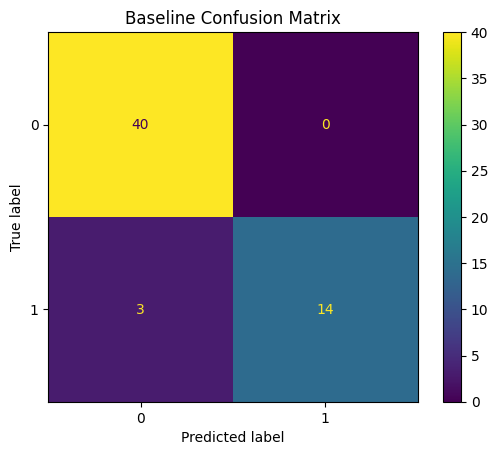

In [1]:
# ==========================================
# Nikita Porwal | Data Science Portfolio
# Project: Cancer Classification using kNN
# ==========================================

# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import math

# ===============================
# LOAD DATA
# ===============================
# Upload file in Colab:
# Go to Files → Upload → select cancerdata.csv

data = pd.read_csv("cancerdata.csv")

print("Data Loaded Successfully")
data.head()

# ===============================
# DATA CLEANING
# ===============================
# Remove unnecessary column
if "id" in data.columns:
    data.drop(columns=["id"], inplace=True)

# Convert diagnosis column into numeric
def convert_diagnosis(value):
    if value == "M":
        return 1
    else:
        return 0

data["diagnosis"] = data["diagnosis"].apply(convert_diagnosis)

print("\n Data Cleaning Done")

# ===============================
# SPLIT DATA
# ===============================
X = data.drop(columns=["diagnosis"])
y = data["diagnosis"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.1, random_state=42
)

print("Data Split Completed")

# ===============================
# BASELINE MODEL (kNN)
# ===============================
# Choosing initial k
k = int(round(math.sqrt(X_train.shape[0]), 0))
print(f"\nInitial k value: {k}")

knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("\nBaseline Model Performance:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Baseline Confusion Matrix")
plt.show()

# ===============================
# 🔧 HYPERPARAMETER TUNING
# ===============================
